# Лабораторна робота №2
*Тема:* Аналіз даних. Робота з даними CSV.

*Виконав:* Волошин Михайло

*Група:* 3-9

Завдання 1.Аналіз Global YouTube Statistics 2023

Завантаження даних

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os
path_yt = kagglehub.dataset_download("nelgiriyewithana/global-youtube-statistics-2023")
file_path = os.path.join(path_yt, "Global YouTube Statistics.csv")
df_yt = pd.read_csv(file_path, encoding='latin-1')
df_yt.head()

100%|██████████| 60.1k/60.1k [00:00<00:00, 39.5MB/s]

Extracting files...


,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


Огляд структури

In [ ]:
print(f"Розмір датасету: {df_yt.shape}")
print("Кількість пропусків:")
print(df_yt.isna().sum())
numeric_cols = df_yt.select_dtypes(include=[np.number]).columns

Розмір датасету: (995, 28)
Кількість пропусків:
rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year                                 5
created_mont

Обробка пропусків

In [ ]:
for col in numeric_cols:
    df_yt[col] = df_yt[col].fillna(df_yt[col].mean()).astype(float)
print("Пропуски після обробки:")
print(df_yt[numeric_cols].isna().sum())

Пропуски після обробки:
rank                                       0
subscribers                                0
video views                                0
uploads                                    0
video_views_rank                           0
country_rank                               0
channel_type_rank                          0
video_views_for_the_last_30_days           0
lowest_monthly_earnings                    0
highest_monthly_earnings                   0
lowest_yearly_earnings                     0
highest_yearly_earnings                    0
subscribers_for_last_30_days               0
created_year                               0
created_date                               0
Gross tertiary education enrollment (%)    0
Population                                 0
Unemployment rate                          0
Urban_population                           0
Latitude                                   0
Longitude                                  0
dtype: int64


Аналіз та візуалізація

Унікальних країн: 49


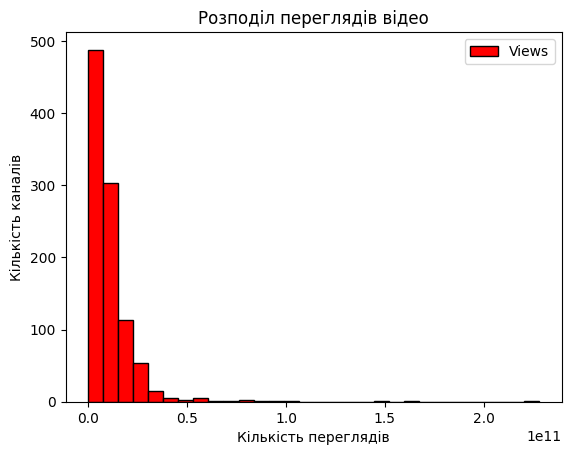

Макс. переглядів: 228000000000.0
Мін. переглядів: 0.0
Середні перегляди: 11039537052.03819


In [ ]:
unique_countries = df_yt['Country'].nunique()
print(f"Унікальних країн: {unique_countries}")
df_yt['video views'].plot(kind='hist', bins=30, color='red', edgecolor='black', label='Views')
plt.title('Розподіл переглядів відео')
plt.xlabel('Кількість переглядів')
plt.ylabel('Кількість каналів')
plt.legend()
plt.show()
print(f"Макс. переглядів: {df_yt['video views'].max()}")
print(f"Мін. переглядів: {df_yt['video views'].min()}")
print(f"Середні перегляди: {df_yt['video views'].mean()}")

Пошук лідерів

In [ ]:
top_country = df_yt.groupby('Country')['uploads'].sum().idxmax()
print(f"Країна з найбільшою кількістю завантажень: {top_country}")
max_up = df_yt.loc[df_yt['uploads'].idxmax(), 'Title']
min_up = df_yt.loc[df_yt['uploads'].idxmin(), 'Title']
print(f"Найбільше завантажень у каналу: {max_up}")
print(f"Найменше завантажень у каналу: {min_up}")

Країна з найбільшою кількістю завантажень: India
Найбільше завантажень у каналу: ABP NEWS
Найменше завантажень у каналу: Music


Завдання 2. Аналіз датасету Amazon Top 50 Bestselling Books

Завантаження та огляд даних

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import os
path_amazon = kagglehub.dataset_download("sootersaalu/amazon-top-50-bestselling-books-2009-2019")
file_path_amazon = os.path.join(path_amazon, "bestsellers with categories.csv")
df = pd.read_csv(file_path_amazon)
display(df.head(10))
print(f"Розміри датасету: {df.shape}")
print(f"Датасет містить дані про {df.shape[0]} записів (книг).")

Using Colab cache for faster access to the 'amazon-top-50-bestselling-books-2009-2019' dataset.


,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
5,A Dance with Dragons (A Song of Ice and Fire),George R. R. Martin,4.4,12643,11,2011,Fiction
6,A Game of Thrones / A Clash of Kings / A Storm...,George R. R. Martin,4.7,19735,30,2014,Fiction
7,A Gentleman in Moscow: A Novel,Amor Towles,4.7,19699,15,2017,Fiction
8,"A Higher Loyalty: Truth, Lies, and Leadership",James Comey,4.7,5983,3,2018,Non Fiction
9,A Man Called Ove: A Novel,Fredrik Backman,4.6,23848,8,2016,Fiction


Розміри датасету: (550, 7)
Датасет містить дані про 550 записів (книг).


Очищення та перевірка даних

In [ ]:
df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']
print("Кількість пропусків у стовпцях:")
print(df.isna().sum())
unique_genres = df['genre'].unique()
print(f"Унікальні жанри: {unique_genres}")
print("\nКількість записів за жанрами:")
print(df['genre'].value_counts())

Кількість пропусків у стовпцях:
name           0
author         0
user_rating    0
reviews        0
price          0
year           0
genre          0
dtype: int64
Унікальні жанри: ['Non Fiction' 'Fiction']

Кількість записів за жанрами:
genre
Non Fiction    310
Fiction        240
Name: count, dtype: int64


Статистика цін та візуалізація

Максимальна ціна: 105
Мінімальна ціна: 0
Середня ціна: 13.10
Медіанна ціна: 11.0


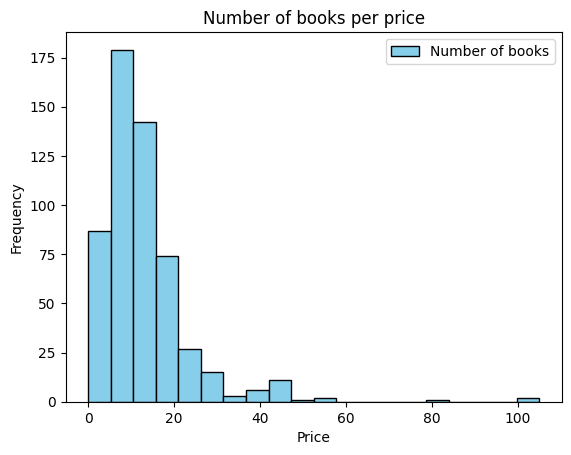

In [ ]:
print(f"Максимальна ціна: {df['price'].max()}")
print(f"Мінімальна ціна: {df['price'].min()}")
print(f"Середня ціна: {df['price'].mean():.2f}")
print(f"Медіанна ціна: {df['price'].median()}")
df['price'].plot(kind='hist', bins=20, label='Number of books', color='skyblue', edgecolor='black')
plt.xlabel('Price')
plt.title('Number of books per price')
plt.legend()
plt.show()

Пошук і сортування даних

In [ ]:
max_rating = df['user_rating'].max()
print(f"Найвищий рейтинг: {max_rating}")
books_with_max_rating = df[df['user_rating'] == max_rating].shape[0]
print(f"Кількість книг з найвищим рейтингом: {books_with_max_rating}")
book_max_reviews = df[df['reviews'] == df['reviews'].max()]['name'].iloc[0]
print(f"Книга з найбільшою кількістю відгуків: '{book_max_reviews}'")
expensive_2010 = df[df['year'] == 2010].sort_values('price', ascending=False).iloc[0]
print(f"Найдорожча книга у 2010 році: '{expensive_2010['name']}' (Ціна: {expensive_2010['price']})")
fiction_2012 = df[(df['year'] == 2012) & (df['genre'] == 'Fiction')].shape[0]
print(f"Кількість книг жанру Fiction у 2012 році: {fiction_2012}")
rating_49 = df[(df['user_rating'] == 4.9) & ((df['year'] == 2010) | (df['year'] == 2011))].shape[0]
print(f"Книг з рейтингом 4.9 у 2010 та 2011 роках: {rating_49}")
price_by_genre = df.groupby(['genre'])[['price']].agg([np.min, np.max])
print("\nМаксимальна і мінімальна ціна за жанрами:")
display(price_by_genre)

Найвищий рейтинг: 4.9
Кількість книг з найвищим рейтингом: 52
Книга з найбільшою кількістю відгуків: 'Where the Crawdads Sing'
Найдорожча книга у 2010 році: 'Publication Manual of the American Psychological Association, 6th Edition' (Ціна: 46)
Кількість книг жанру Fiction у 2012 році: 21
Книг з рейтингом 4.9 у 2010 та 2011 роках: 1

Максимальна і мінімальна ціна за жанрами:


/tmp/ipython-input-704/1026549933.py:13: FutureWarning: The provided callable <function min at 0x7ba815dc91c0> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  price_by_genre = df.groupby(['genre'])[['price']].agg([np.min, np.max])
/tmp/ipython-input-704/1026549933.py:13: FutureWarning: The provided callable <function max at 0x7ba815dc9080> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  price_by_genre = df.groupby(['genre'])[['price']].agg([np.min, np.max])


price     
              min  max
genre                 
Fiction         0   82
Non Fiction     0  105

Додатковий аналіз

In [ ]:
author_books = df.groupby(['author'])[['name']].count()
avg_author_rating = df.groupby(['author'])[['user_rating']].agg(np.mean).round(1)
top_author = author_books[author_books['name'] == author_books['name'].max()]
print("Автор з найбільшою кількістю книг:")
display(top_author)
min_rating_author = avg_author_rating[avg_author_rating['user_rating'] == avg_author_rating['user_rating'].min()]
print("\nАвтор з найнижчим середнім рейтингом:")
display(min_rating_author)
book_and_rating = pd.concat([avg_author_rating, author_books], axis=1)
book_and_rating.columns = ['avg_rating', 'books_count']
print("\nЗведена таблиця по авторах:")
display(book_and_rating.head(10))

Автор з найбільшою кількістю книг:


/tmp/ipython-input-704/789525769.py:2: FutureWarning: The provided callable <function mean at 0x7ba815dc9a80> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  avg_author_rating = df.groupby(['author'])[['user_rating']].agg(np.mean).round(1)


,name
author,
Jeff Kinney,12



Автор з найнижчим середнім рейтингом:


,user_rating
author,
Donna Tartt,3.9



Зведена таблиця по авторах:


,avg_rating,books_count
author,,
Abraham Verghese,4.6,2
Adam Gasiewski,4.4,1
Adam Mansbach,4.8,1
Adir Levy,4.8,1
Admiral William H. McRaven,4.7,1
Adult Coloring Book Designs,4.5,1
Alan Moore,4.8,1
Alex Michaelides,4.5,1
Alice Schertle,4.9,1
